<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
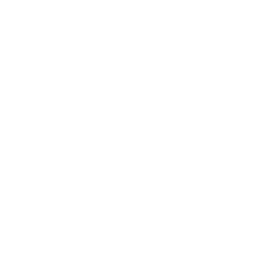
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Diagnostika poruchy chemického reaktoru</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Identifikace proměnných způsobujících překročení T2 reaktoru během poruchy &nbsp;|&nbsp; Březen 2026</p>
</div>
</div>
</div>

## Shrnutí

Kontinuální míchaný reaktor (CSTR) sklouzl do tepelné poruchy, když
selhal jeho přívod chladiva. Za normálního provozu se průtok
chladiva, teplota reaktoru a teplota chladicího pláště pohybují
společně podél jediné osy procesní zátěže. Sestavíme třísložkový
model MVP na 100 pozorováních za normálního provozu a poté proti
němu vyhodnotíme 100 pozorování z poruchové události pomocí
`PROC MVPDIAGNOSE`. Rozklad Hotellingovy statistiky *T*-kvadrát na
příspěvky jednotlivých proměnných izoluje tepelně provázanou trojici
— `jacket_temp`, `coolant_flow` a `reactor_temp` — jako proměnné,
které způsobují překročení meze, což směřuje pozornost provozu přímo
na subsystém chlazení.

## Zdroje dat

| Dataset | Role | Pozorování |
|---|---|---|
| `reactor_normal` | Trénovací data normálního provozu pro model MVP | 100 |
| `reactor_upset` | Pozorování z poruchové události vyhodnocená proti modelu | 100 |

Šest měřených proměnných je `reactor_temp` (C), `coolant_flow`
(L/min), `jacket_temp` (C), `feed_conc` (g/L) a `pressure` (bar).
Oba datasety jsou simulovány ze sdílené latentní *procesní zátěže*,
takže normální data nesou stejnou korelační strukturu jako skutečný
CSTR; porucha vnáší ztrátu přívodu chladiva, která tuto strukturu
naruší.

## Krok 1 — Trénování modelu MVP pro normální provoz

Normální provoz je řízen latentní procesní zátěží: vyšší zátěž
snižuje průtok chladiva a zároveň zvyšuje teplotu reaktoru a
chladicího pláště. `PROC MVPMODEL` extrahuje tři hlavní komponenty
ze 100 normálních pozorování a uloží je pomocí `OUTMODEL=`, aby krok
diagnózy mohl proti stejné referenci vyhodnotit nová data.

In [1]:
data reactor_normal;
  CALL streaminit(7);
  OPAKUJ t = 1 TO 100;
    LOAD = rand('normal', 0, 1);                 /* latentní procesní zátěž */
    reactor_temp = 85.0 + 2.5*LOAD + rand('normal', 0, 0.5);
    coolant_flow = 45.0 - 3.0*LOAD + rand('normal', 0, 0.6);
    jacket_temp  = 22.0 + 1.8*LOAD + rand('normal', 0, 0.4);
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*LOAD + rand('normal', 0, 0.05);
    VÝSTUP;
  KONEC;
SPUSTIT;

PROC MVPMODEL data=reactor_normal outmodel=reactor_model;
  PROMĚNNÁ reactor_temp coolant_flow jacket_temp feed_conc pressure;
  ncomp=3;
SPUSTIT;


                    The MVPMODEL Procedure

  Data Set:          reactor_normal
  Number of Variables: 5
  Missing Value Handling: Exclude
  Number of Observations Read: 100
  Number of Observations Used: 100
  Number of Principal Components: 3

  Correlation Matrix
         reactor_tempcoolant_flowjacket_temp feed_conc  pressure
  reactor_temp    1.0000   -0.9611    0.9530   -0.0726    0.9662
  coolant_flow   -0.9611    1.0000   -0.9636    0.0281   -0.9712
  jacket_temp    0.9530   -0.9636    1.0000    0.0008    0.9720
  feed_conc   -0.0726    0.0281    0.0008    1.0000   -0.0326
  pressure    0.9662   -0.9712    0.9720   -0.0326    1.0000

  Eigenvalues of the Correlation Matrix
       Eigenvalue   Difference   Proportion  Cumulative
    1 3.89511286  2.89376076    0.7790    0.7790
    2 1.00135210  0.95664889    0.2003    0.9793
    3 0.04470321                0.0089    0.9882




NOTE: DATA reactor_normal


NOTE: Wrote reactor_normal (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPMODEL
NOTE: PROC MVPMODEL statement used.


## Krok 2 — Vyhodnocení poruchové události a rozklad *T*-kvadrát

Porucha sníží průtok chladiva zhruba o 12 L/min, zatímco teplota
reaktoru i chladicího pláště stoupá — normální provázanost chladiva
a teploty je narušena. `PROC MVPDIAGNOSE` vyhodnotí každé pozorování
z poruchové události proti referenčnímu modelu a zapíše
standardizovaná skóre a rezidua do `OUT=` a příspěvky jednotlivých
proměnných k *T*-kvadrát do `OUTCONTRIB=`. Každé pozorování se ocitá
daleko za regulační mezí, což potvrzuje trvalý vícerozměrný exkurz,
nikoli izolovaný šum.

In [2]:
data reactor_upset;
  CALL streaminit(101);
  OPAKUJ t = 1 TO 100;
    LOAD = rand('normal', 0, 1);
    /* Chladicí čerpadlo degraduje: průtok klesá, teploty utíkají */
    reactor_temp = 85.0 + 2.5*LOAD + rand('normal', 0, 0.5) + 8.0;
    coolant_flow = 45.0 - 3.0*LOAD + rand('normal', 0, 0.6) - 12.0;
    jacket_temp  = 22.0 + 1.8*LOAD + rand('normal', 0, 0.4) + 5.0;
    feed_conc    =  2.4 + rand('normal', 0, 0.08);
    pressure     =  3.2 + 0.4*LOAD + rand('normal', 0, 0.05);
    obs_time = t;
    VÝSTUP;
  KONEC;
SPUSTIT;

PROC MVPDIAGNOSE data=reactor_upset MODEL=reactor_model
                 out=reactor_scores;
  PROMĚNNÁ reactor_temp coolant_flow jacket_temp feed_conc pressure;
  id obs_time;
  outcontrib=reactor_contrib;
SPUSTIT;


                    The MVPDIAGNOSE Procedure

  Variables:           5
  Observations:        100
  T-squared limit:     14.8750
  Out-of-control:      100

  Out-of-control observations:
    Obs 1: T2 = 2090.8063
    Obs 2: T2 = 999.7924
    Obs 3: T2 = 1527.3324
    Obs 4: T2 = 2991.6777
    Obs 5: T2 = 3777.1420
    Obs 6: T2 = 1902.6525
    Obs 7: T2 = 3769.1715
    Obs 8: T2 = 2615.9714
    Obs 9: T2 = 1143.3295
    Obs 10: T2 = 3332.9549
    Obs 11: T2 = 2752.9890
    Obs 12: T2 = 2494.0743
    Obs 13: T2 = 3270.5544
    Obs 14: T2 = 5566.4499
    Obs 15: T2 = 3268.5867
    Obs 16: T2 = 3393.2374
    Obs 17: T2 = 1646.0731
    Obs 18: T2 = 2328.4410
    Obs 19: T2 = 1748.7747
    Obs 20: T2 = 3117.7899
    ... and 80 more





NOTE: DATA reactor_upset


NOTE: Wrote reactor_upset (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MVPDIAGNOSE
NOTE: PROC MVPDIAGNOSE statement used.


## Krok 3 — Seřazení průměrných příspěvků

`OUTCONTRIB=` zapíše jeden řádek na každé vyhodnocené pozorování se
sloupcem `<variable>_CONTRIB` pro každou procesní proměnnou.
Zprůměrováním těchto sloupců získáme průměrný příspěvek každé
proměnné k poruše; transpozice pak přetvoří jednořádkový souhrn na
přehlednou tabulku proměnná/hodnota, která seřadí hnací činitele
poruchy.

In [3]:
PROC MEANS data=reactor_contrib mean NOPRINT;
  PROMĚNNÁ reactor_temp_contrib coolant_flow_contrib jacket_temp_contrib
      feed_conc_contrib pressure_contrib;
  VÝSTUP out=contrib_means
    mean=mc_reactor_temp mc_coolant_flow mc_jacket_temp
         mc_feed_conc mc_pressure;
SPUSTIT;

PROC TRANSPOSE data=contrib_means out=contrib_long name=metric;
  PROMĚNNÁ mc_reactor_temp mc_coolant_flow mc_jacket_temp
      mc_feed_conc mc_pressure;
SPUSTIT;

/* Přiřadit čitelné názvy proměnných a hodnotu průměrného příspěvku */
data contrib_ranked;
  NASTAVIT contrib_long;
  DÉLKA variable $40;
  KDYŽ      metric = 'mc_reactor_temp' PAK variable = 'Teplota reaktoru';
  JINAK KDYŽ metric = 'mc_coolant_flow' PAK variable = 'Průtok chladiva';
  JINAK KDYŽ metric = 'mc_jacket_temp'  PAK variable = 'Teplota chladicího pláště';
  JINAK KDYŽ metric = 'mc_feed_conc'    PAK variable = 'Koncentrace nástřiku';
  JINAK KDYŽ metric = 'mc_pressure'     PAK variable = 'Tlak';
  mean_contrib = col1;
  PONECHAT variable mean_contrib;
SPUSTIT;

PROC SORT data=contrib_ranked;
  PODLE SESTUPNĚ mean_contrib;
SPUSTIT;

PROC PRINT data=contrib_ranked noobs;
  PROMĚNNÁ variable mean_contrib;
  ŠTÍTEK variable='Proměnná procesu' mean_contrib='Průměrný příspěvek T-kvadrát';
SPUSTIT;


             Proměnná procesu         Průměrný příspěvek T-kvadrát
-----------------------------  -----------------------------------
Teplota chladicího pláště                            4177.66720283
Průtok chladiva                                      2882.19501987
Teplota reaktoru                                     1602.04200377
Tlak                                                  280.73140863
Koncentrace nástřiku                                   61.43535437




NOTE: PROC MEANS
NOTE: Output dataset contrib_means has 1 observations and 7 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC TRANSPOSE data=contrib_means

NOTE: Created 5 rows.
NOTE: Output written to ./work/48b1c52f-05b5-4924-baad-661b7c9e08d4/contrib_long.avro.
NOTE: DATA contrib_ranked


NOTE: Read 5 rows from contrib_long.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=contrib_ranked

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 5 rows from contrib_ranked.
NOTE: Wrote contrib_ranked (5 rows, 2 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=contrib_ranked

NOTE: PROC PRINT completed: 5 observations printed, 2 variables


## Krok 4 — Graf příspěvků

Graf příspěvků učiní diagnózu okamžitě zřejmou: tepelně provázaná
trojice — `jacket_temp`, `coolant_flow` a `reactor_temp` — zastiňuje
`feed_conc` a `pressure`, které se sotva projeví. Tři dominantní
sloupce jsou přesně proměnné svázané chladicím okruhem, takže
porucha je jednoznačně tepelná, nikoli problém s nástřikem nebo
tlakem.


NOTE: PROC SGPLOT data=contrib_ranked

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


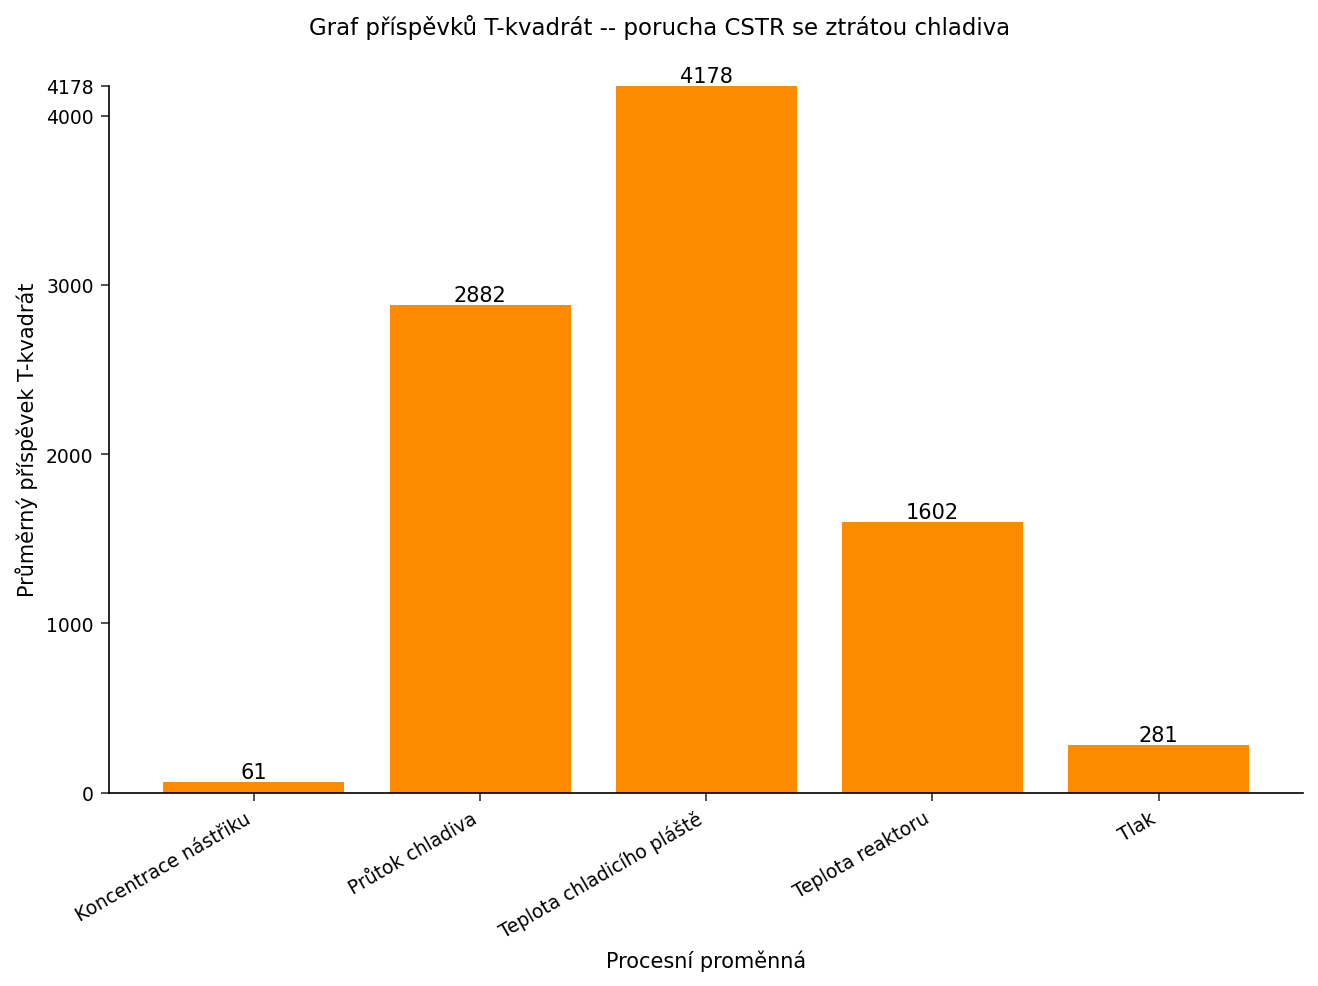

In [4]:
PROC SGPLOT data=contrib_ranked;
  VBAR variable / RESPONSE=mean_contrib
                  fillattrs=(color=darkorange)
                  DATALABEL;
  XAXIS ŠTÍTEK='Procesní proměnná';
  YAXIS ŠTÍTEK='Průměrný příspěvek T-kvadrát';
  NÁZEV 'Graf příspěvků T-kvadrát -- porucha CSTR se ztrátou chladiva';
SPUSTIT;

## Krok 5 — Časový průběh regulace *T*-kvadrát

Vynesení hodnoty *T*-kvadrát každého pozorování proti regulační mezi
modelu ukazuje, že exkurz je nepřetržitý: každé pozorování z poruchy
se nachází o řády nad referenční mezní čárou. V rámci okna nedochází
k žádné obnově, což odpovídá poruše hardwaru, která přetrvává, dokud
není subsystém chlazení opraven.


NOTE: PROC SGPLOT data=reactor_scores

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


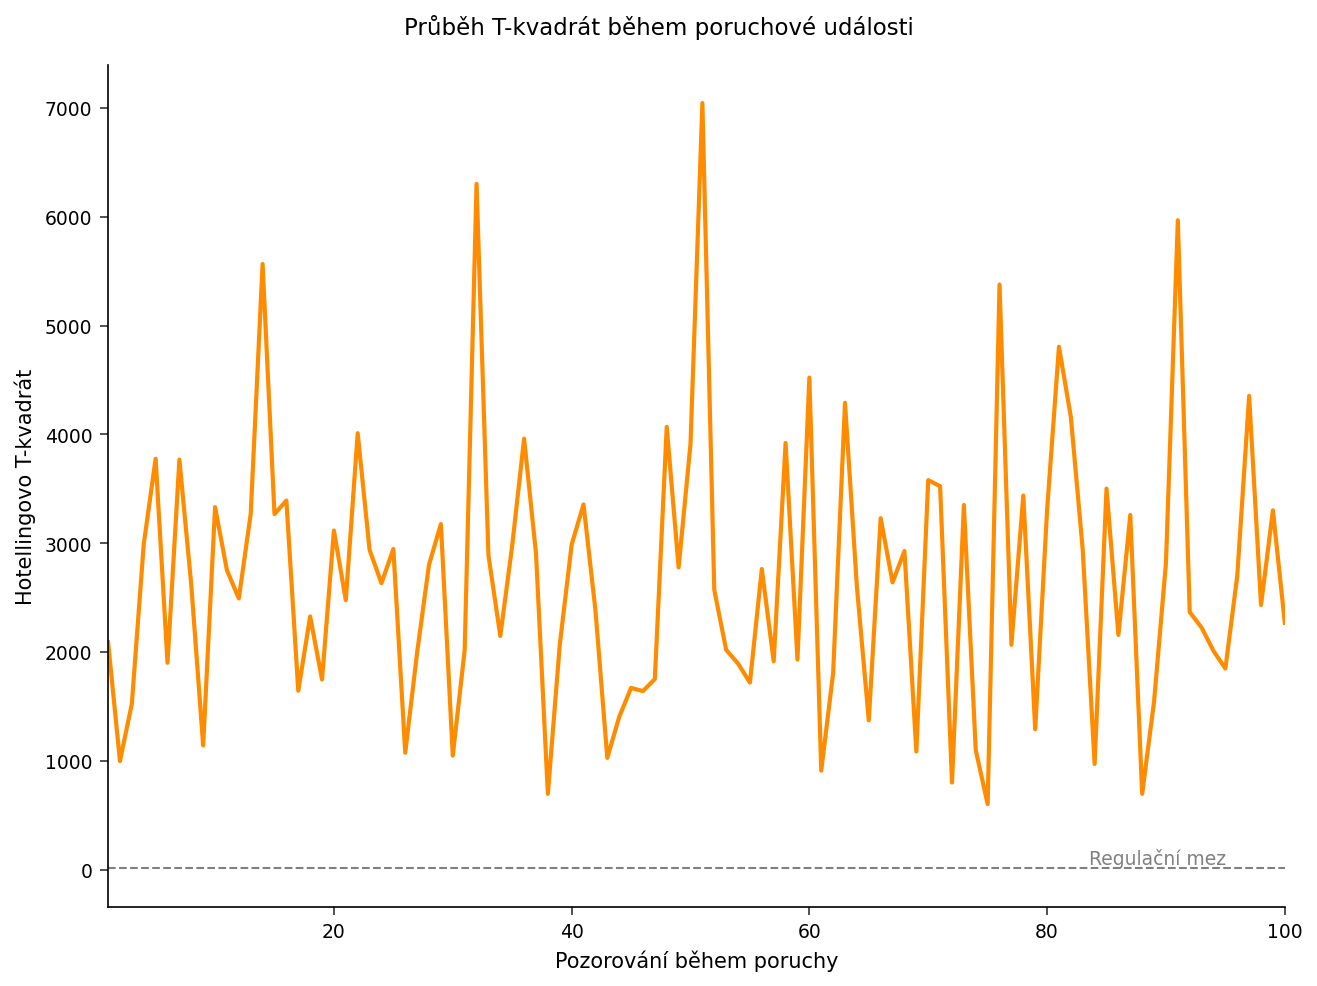

In [5]:
PROC SGPLOT data=reactor_scores;
  SERIES x=_OBS y=_TSQUARED / LINEATTRS=(color=darkorange thickness=2);
  REFLINE 14.87 / AXIS=y
                  ŠTÍTEK='Regulační mez'
                  LINEATTRS=(pattern=dash color=gray);
  XAXIS ŠTÍTEK='Pozorování během poruchy';
  YAXIS ŠTÍTEK='Hotellingovo T-kvadrát';
  NÁZEV 'Průběh T-kvadrát během poruchové události';
SPUSTIT;

## Zjištění a nápravné opatření

- **Hlavní hnací činitelé**: `jacket_temp`, `coolant_flow` a
  `reactor_temp` dohromady tvoří v podstatě celý signál *T*-kvadrát;
  jejich průměrné příspěvky (4178, 2882 a 1602) jsou zhruba o jeden
  až dva řády vyšší než u `feed_conc` (61) a `pressure` (281).
- **Hlavní příčina**: ztráta přívodu chladiva. `coolant_flow` je
  jedinou *řízenou* proměnnou ze tří — nárůsty teploty jsou
  následkem ztráty chlazení, takže akční poruchou je subsystém
  chlazení.
- **Stav regulace**: všech 100 pozorování z poruchy překračuje mez
  *T*-kvadrát, což ukazuje na trvalý exkurz, nikoli přechodný jev.
- **Nápravné opatření**: zkontrolovat a repasovat chladicí čerpadlo;
  přidat záložní snímač průtoku chladiva, aby budoucí ztráta přívodu
  byla zachycena jednorozměrným hlášením alarmu dříve, než se
  rozšíří do teplotní smyčky.

## Export seřazených příspěvků

Seřazená tabulka příspěvků je zapsána do CSV pro zprávu po události
a navazující dashboardy.

In [6]:
PROC EXPORT data=contrib_ranked
            OUTFILE='reactor_upset_contributions.csv'
            DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=contrib_ranked outfile=reactor_upset_contributions.csv

NOTE: Exported 5 rows to reactor_upset_contributions.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>